In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from scipy.stats import spearmanr

In [2]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY-"

def extract_features(sequence):
    sequence = sequence.upper()
    seq_len = len(sequence)
    counts = {aa: sequence.count(aa)/seq_len for aa in amino_acids}
    analysis = ProteinAnalysis(sequence.replace("-", ""))
    features = counts.copy()
    features["Hydrophobicity"] = analysis.gravy()
    features["Isoelectric point"] = analysis.isoelectric_point()
    features["Aromaticity"] = analysis.aromaticity()
    features["Instability index"] = analysis.instability_index()
    features["Molecular weight"] = analysis.molecular_weight()
    features["Charge"] = analysis.charge_at_pH(7.0)
    
    return features

In [3]:
train_df = pd.read_csv(r"D:\Thesis - November\Dataset\Clustering\new_90 percent\data\train_data.csv")

In [4]:
train_cdr1 = pd.DataFrame.from_records([extract_features(cdr) for cdr in train_df['CDR1 aligned']])
train_cdr2 = pd.DataFrame.from_records([extract_features(cdr) for cdr in train_df['CDR2 aligned']])
train_cdr3 = pd.DataFrame.from_records([extract_features(cdr) for cdr in train_df['CDR3 aligned']])


In [5]:
train_cdr1.columns = [f"CDR1_{aa}" for aa in train_cdr1.columns]
train_cdr2.columns = [f"CDR2_{aa}" for aa in train_cdr2.columns]
train_cdr3.columns = [f"CDR3_{aa}" for aa in train_cdr3.columns]

In [6]:
x_train = pd.concat([train_cdr1, train_cdr2, train_cdr3], axis=1)

In [7]:
print(train_df.columns.tolist())


['Cluster_name', 'Nanobody_id', 'Label', 'Sequence', 'CDR1', 'CDR2', 'CDR3', 'CDR1 aligned', 'CDR2 aligned', 'CDR3 aligned', 'Aligned Sequence']


In [8]:
df_pos = train_df.index[train_df["Label"] == 0]
cdr_cols = ["CDR1_Charge", "CDR2_Charge", "CDR3_Charge"]
cdr_data = x_train.loc[df_pos, cdr_cols]

In [9]:
corr_matrix = cdr_data.corr(method="spearman")
print(corr_matrix)

             CDR1_Charge  CDR2_Charge  CDR3_Charge
CDR1_Charge     1.000000    -0.013635    -0.042520
CDR2_Charge    -0.013635     1.000000    -0.036951
CDR3_Charge    -0.042520    -0.036951     1.000000


In [10]:
for cdr in cdr_cols:
    print(cdr_data[cdr].describe())


count    51507.000000
mean        -0.359253
std          0.887423
min         -4.233233
25%         -1.236596
50%         -0.240897
75%         -0.154722
max          3.759073
Name: CDR1_Charge, dtype: float64
count    51507.000000
mean        -0.406274
std          0.577418
min         -3.236536
25%         -0.240897
50%         -0.239898
75%         -0.239898
max          1.759093
Name: CDR2_Charge, dtype: float64
count    51507.000000
mean        -0.628528
std          1.454214
min         -7.201275
25%         -1.206002
50%         -0.207122
75%         -0.028975
max          4.880002
Name: CDR3_Charge, dtype: float64


In [11]:
pairs = [
    ("CDR1_Charge", "CDR2_Charge"),
    ("CDR1_Charge", "CDR3_Charge"),
    ("CDR2_Charge", "CDR3_Charge"),
]

for a, b in pairs:
    rho, p = spearmanr(cdr_data[a], cdr_data[b])
    print(f"{a} vs {b}: rho={rho:.3f}, p={p:.3e}")


CDR1_Charge vs CDR2_Charge: rho=-0.014, p=1.971e-03
CDR1_Charge vs CDR3_Charge: rho=-0.043, p=4.719e-22
CDR2_Charge vs CDR3_Charge: rho=-0.037, p=4.916e-17


In [12]:
def charge_bin(x, eps=0):
    if x < -eps:
        return "neg"
    elif x > eps:
        return "pos"
    else:
        return "neutral"

for cdr in cdr_cols:
    cdr_data[f"{cdr}_bin"] = cdr_data[cdr].apply(charge_bin)


In [13]:
combo_counts = (
    cdr_data
    .groupby(["CDR1_Charge_bin", "CDR2_Charge_bin", "CDR3_Charge_bin"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

combo_counts["Frequency"] = combo_counts["count"] / combo_counts["count"].sum()
print(combo_counts.head)


<bound method NDFrame.head of   CDR1_Charge_bin CDR2_Charge_bin CDR3_Charge_bin  count  Frequency
0             neg             neg             neg  27635   0.536529
1             neg             neg             pos   9757   0.189431
4             pos             neg             neg   7857   0.152542
2             neg             pos             neg   2566   0.049818
5             pos             neg             pos   2147   0.041684
3             neg             pos             pos    699   0.013571
6             pos             pos             neg    691   0.013416
7             pos             pos             pos    155   0.003009>


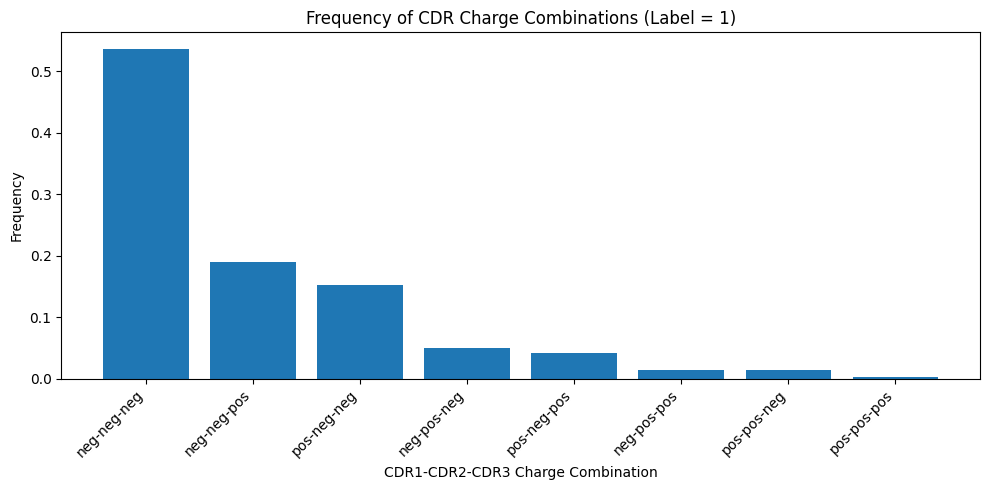

In [14]:
combo_counts["combo"] = (
    combo_counts["CDR1_Charge_bin"] + "-" +
    combo_counts["CDR2_Charge_bin"] + "-" +
    combo_counts["CDR3_Charge_bin"]
)

plt.figure(figsize=(10, 5))
plt.bar(combo_counts["combo"], combo_counts["Frequency"])
plt.ylabel("Frequency")
plt.xlabel("CDR1-CDR2-CDR3 Charge Combination")
plt.xticks(rotation=45, ha="right")
plt.title("Frequency of CDR Charge Combinations (Label = 1)")
plt.tight_layout()
plt.show()


In [15]:
pd.crosstab(
    cdr_data["CDR1_Charge_bin"],
    cdr_data["CDR3_Charge_bin"],
    normalize="index"
)



CDR3_Charge_bin,neg,pos
CDR1_Charge_bin,,
neg,0.742824,0.257176
pos,0.787834,0.212166
